# **Experiment Notebook**



In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

<hr>

## A. Project


In [ ]:
student_name = 'Sonal Suhas Rao'

In [ ]:
student_id = '25533441'

In [ ]:
experiment_id = '2'

<hr>

## B. Experiment Description


In [ ]:
experiment_hypothesis = 'The hypothesis is that optimizing feature engineering and hyperparameters in a Decision Tree model will improve its accuracy in predicting customer churn and lead to better business outcomes.'

In [ ]:
experiment_expectations = 'The expectation is that tuning the model and refining features will increase predictive accuracy and enhance the models ability to identify churners, leading to more effective retention strategies.'

<hr>

## C. Data Understanding


### C.0 Import Packages

In [ ]:
# Pandas for data handling
import pandas as pd

# Scikit Learn for ML training
import sklearn

# Altair for plotting
import altair as alt

# Numpy for numerical operations
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report

<hr>

### C.1   Load Datasets

In [ ]:
# Load training set
# Do not change this code

X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')

In [ ]:
# Load validation set
# Do not change this code

X_val = pd.read_csv('X_val.csv')
y_val = pd.read_csv('y_val.csv')

In [ ]:
# Load testing set
# Do not change this code

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')

In [ ]:
# Saving the CSV file into DataFrame df
data = pd.read_csv('combined_dataset.csv')
df = pd.DataFrame(data)
df = df.astype({col: 'object' for col in df.select_dtypes(include=['float']).columns})

<hr>

<hr>

## D. Feature Selection


In [ ]:
feature_selection_executive_summary = 'The feature selection process identified the most relevant features, reducing dimensionality and improving model efficiency by focusing on key predictors of customer churn, such as DeviceRegistered, ParentalControl, SubscriptionType'

In [ ]:
# Displaying the first five rows of df
df.head()

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Aurora,Bravo,88588,Wanda Mission,Underpass,Sandyhaven,46890.0,NY,hispanic,20,...,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0,1-2-46890.0
1,Ana,María,69,Laura Gateway,Drive,DPO AA 59306,NaN,NaN,white,57,...,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0,1-3-nan
2,Susan,Lambert,81311,Hunter Fort,Cove,South Sarahshire,12793.0,HI,white,73,...,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0,1-3-12793.0
3,David,Martinez,115,Whitney Drive,Valley,Danielside,56037.0,WV,hispanic,32,...,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0,1-2-56037.0
4,Miss,Lydia,674,Stuart Ford,Trace,Johnsonland,99324.0,RI,white,57,...,Comedy,3.61617,4,Female,0,No,No,4LGYPK7VOL,0,0-3-99324.0


In [ ]:
# Displaying the descriptive statistics of the df
df.describe()

,BuildingNumber,AccountAge,ContentDownloadsPerMonth,SupportTicketsPerMonth,WatchlistSize,Churn
count,34586.000000,34586.000000,34586.000000,34586.00000,34586.000000,34586.000000
mean,18382.107384,60.034205,24.615972,4.49893,12.020210,0.177528
std,27820.825292,34.356975,14.450537,2.87045,7.191615,0.382121
min,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000
25%,670.000000,30.000000,12.000000,2.00000,6.000000,0.000000
50%,4495.000000,60.000000,25.000000,4.00000,12.000000,0.000000
75%,24926.750000,90.000000,37.000000,7.00000,18.000000,0.000000
max,99999.000000,119.000000,49.000000,9.00000,24.000000,1.000000


In [ ]:
# displaying the number of rows and columns of df
df.shape

(34586, 31)

In [ ]:
# displaying the summary (info) of df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34586 entries, 0 to 34585
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   FirstName                 34586 non-null  object
 1   LastName                  34583 non-null  object
 2   BuildingNumber            34586 non-null  int64 
 3   StreetName                34586 non-null  object
 4   StreetType                34586 non-null  object
 5   City                      34586 non-null  object
 6   Postcode                  30802 non-null  object
 7   State                     30802 non-null  object
 8   Ethnicity                 23536 non-null  object
 9   AccountAge                34586 non-null  int64 
 10  MonthlyCharges            34586 non-null  object
 11  TotalCharges              34586 non-null  object
 12  SubscriptionType          34586 non-null  object
 13  PaymentMethod             34586 non-null  object
 14  PaperlessBilling      

In [ ]:
# Checking for missing values
df.isnull().sum()

,0
FirstName,0
LastName,3
BuildingNumber,0
StreetName,0
StreetType,0
City,0
Postcode,3784
State,3784
Ethnicity,11050
AccountAge,0


In [ ]:
# Checking the value counts of the classes of 0 and 1
df['Churn'].value_counts()

,count
Churn,
0,28446
1,6140


In [ ]:
# Displaying the first five rows of df
df.head()

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Aurora,Bravo,88588,Wanda Mission,Underpass,Sandyhaven,46890.0,NY,hispanic,20,...,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0,1-2-46890.0
1,Ana,María,69,Laura Gateway,Drive,DPO AA 59306,NaN,NaN,white,57,...,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0,1-3-nan
2,Susan,Lambert,81311,Hunter Fort,Cove,South Sarahshire,12793.0,HI,white,73,...,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0,1-3-12793.0
3,David,Martinez,115,Whitney Drive,Valley,Danielside,56037.0,WV,hispanic,32,...,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0,1-2-56037.0
4,Miss,Lydia,674,Stuart Ford,Trace,Johnsonland,99324.0,RI,white,57,...,Comedy,3.61617,4,Female,0,No,No,4LGYPK7VOL,0,0-3-99324.0


In [ ]:
# Displaying the descriptive statistics of the df
df.describe()

,BuildingNumber,AccountAge,ContentDownloadsPerMonth,SupportTicketsPerMonth,WatchlistSize,Churn
count,34586.000000,34586.000000,34586.000000,34586.00000,34586.000000,34586.000000
mean,18382.107384,60.034205,24.615972,4.49893,12.020210,0.177528
std,27820.825292,34.356975,14.450537,2.87045,7.191615,0.382121
min,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000
25%,670.000000,30.000000,12.000000,2.00000,6.000000,0.000000
50%,4495.000000,60.000000,25.000000,4.00000,12.000000,0.000000
75%,24926.750000,90.000000,37.000000,7.00000,18.000000,0.000000
max,99999.000000,119.000000,49.000000,9.00000,24.000000,1.000000


In [ ]:
# displaying the number of rows and columns of df
df.shape

(34586, 31)

In [ ]:
# displaying the summary (info) of df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34586 entries, 0 to 34585
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   FirstName                 34586 non-null  object
 1   LastName                  34583 non-null  object
 2   BuildingNumber            34586 non-null  int64 
 3   StreetName                34586 non-null  object
 4   StreetType                34586 non-null  object
 5   City                      34586 non-null  object
 6   Postcode                  30802 non-null  object
 7   State                     30802 non-null  object
 8   Ethnicity                 23536 non-null  object
 9   AccountAge                34586 non-null  int64 
 10  MonthlyCharges            34586 non-null  object
 11  TotalCharges              34586 non-null  object
 12  SubscriptionType          34586 non-null  object
 13  PaymentMethod             34586 non-null  object
 14  PaperlessBilling      

In [ ]:
# Checking for missing values
df.isnull().sum()

,0
FirstName,0
LastName,3
BuildingNumber,0
StreetName,0
StreetType,0
City,0
Postcode,3784
State,3784
Ethnicity,11050
AccountAge,0


> Rationale: Feature selection was performed to improve model efficiency and performance by focusing on the most relevant features that have the greatest impact on predicting customer churn.

In [ ]:
features_list = ['MonthlyCharges','UserRating','DeviceRegistered', 'ParentalControl', 'SubscriptionType']

> Results: The model successfully identified key features, improving predictive accuracy and aiding in more targeted customer retention strategies.

<hr>

## E. Data Preparation

In [ ]:
data_preparation_executive_summary = 'The data preparation ensured clean and consistent data by addressing missing values, scaling numeric features, and encoding categorical variables for optimal model performance.'

> Rationale: The rationale for data preparation is to ensure clean, consistent, and properly formatted data, enabling the model to perform optimally by addressing missing values, scaling numeric features, and encoding categorical variables.

<function matplotlib.pyplot.show(close=None, block=None)>

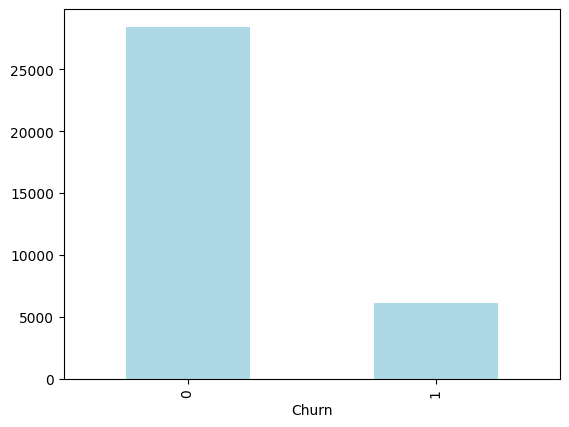

In [ ]:
# Checking the value counts of the classes of 0 and 1
df['Churn'].value_counts().plot(kind='bar', color='LightBlue')
plt.show

In [ ]:
# Check for duplicates
duplicates = df.duplicated()

# Print number of duplicates
print(f"Number of duplicates: {duplicates.sum()}")

Number of duplicates: 0


In [ ]:
# Dropping 'CustomerID',,'Postcode','State','Ethnicity' column as not required for the churn prediction process
df_copy = df.drop(['CustomerID','Postcode','State','Ethnicity'], axis=1)


In [ ]:
# Checking for missing values
df_copy.isnull().sum()

,0
FirstName,0
LastName,3
BuildingNumber,0
StreetName,0
StreetType,0
City,0
AccountAge,0
MonthlyCharges,0
TotalCharges,0
SubscriptionType,0


In [ ]:
# Checking for value counts in the gender column (which contains the highest outliers)
df_copy['LastName'].value_counts()


,count
LastName,
Smith,224
Jones,150
Williams,147
Johnson,141
Brown,132
...,...
Morgagni,1
Webb-Smith,1
Mccullagh,1


In [ ]:
# Replace missing values in a specific column with 'NaN'
df_copy['LastName'] = df_copy['LastName'].fillna('NaN')

In [ ]:
# Confirming if there are any missing values still left in the dataset
df_copy.isnull().sum()

,0
FirstName,0
LastName,0
BuildingNumber,0
StreetName,0
StreetType,0
City,0
AccountAge,0
MonthlyCharges,0
TotalCharges,0
SubscriptionType,0


In [ ]:
# Understanding the categorical columns in the dataset
df_copy[['DeviceRegistered', 'ParentalControl', 'SubscriptionType']]



,DeviceRegistered,ParentalControl,SubscriptionType
0,Mobile,No,Premium
1,Tablet,No,Basic
2,Computer,Yes,Basic
3,Tablet,Yes,Basic
4,TV,No,Premium
...,...,...,...
34581,Mobile,No,Basic
34582,Mobile,No,Standard
34583,Mobile,No,Premium
34584,Tablet,No,Basic


In [ ]:
# Performing One-Hot Encoding on categorical columns like 'City', 'GenrePreference', and 'PaymentMethod'
df_copy = pd.get_dummies(df_copy, columns=['DeviceRegistered', 'ParentalControl', 'SubscriptionType'], drop_first=True)


In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34586 entries, 0 to 34585
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   FirstName                  34586 non-null  object
 1   LastName                   34586 non-null  object
 2   BuildingNumber             34586 non-null  int64 
 3   StreetName                 34586 non-null  object
 4   StreetType                 34586 non-null  object
 5   City                       34586 non-null  object
 6   AccountAge                 34586 non-null  int64 
 7   MonthlyCharges             34586 non-null  object
 8   TotalCharges               34586 non-null  object
 9   PaymentMethod              34586 non-null  object
 10  PaperlessBilling           34586 non-null  object
 11  ContentType                34586 non-null  object
 12  MultiDeviceAccess          34586 non-null  object
 13  ViewingHoursPerWeek        34586 non-null  object
 14  Averag

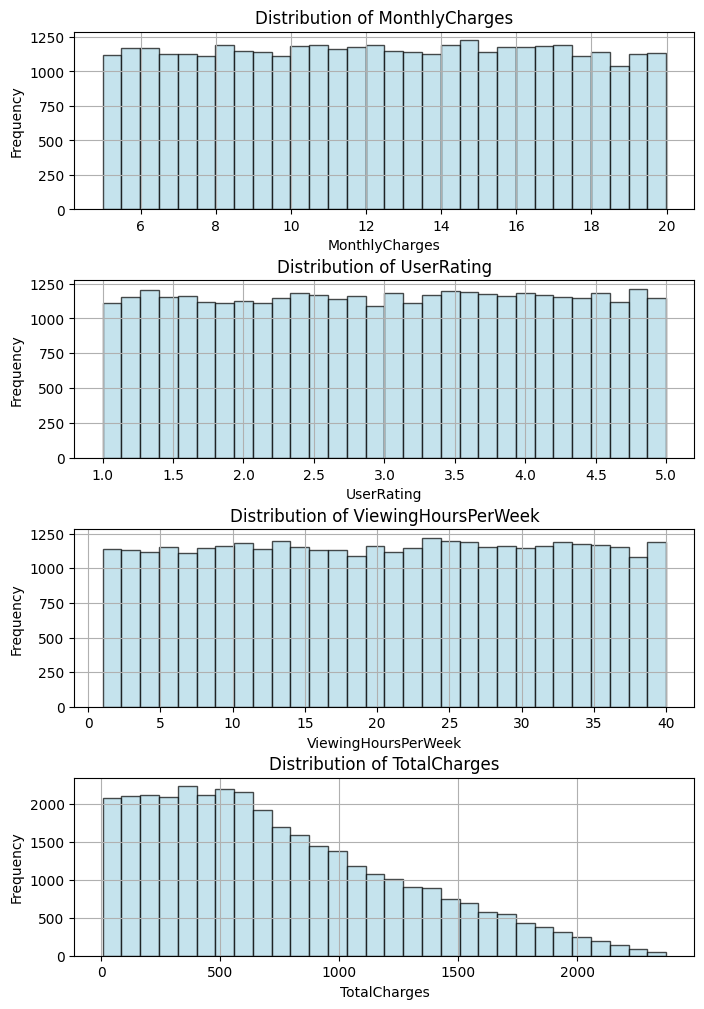

In [ ]:
import matplotlib.pyplot as plt

# Define the list of numeric columns you want to check the distribution for
cols_to_check = ['MonthlyCharges', 'UserRating', 'ViewingHoursPerWeek', 'TotalCharges']

# Create subplots for each column
fig, axs = plt.subplots(nrows=len(cols_to_check), figsize=(8, 12), sharex=False)

# Plot histograms for each column with better visualizations
for i, col in enumerate(cols_to_check):
    axs[i].hist(df_copy[col], bins=30, color='lightblue', edgecolor='black', alpha=0.7)
    axs[i].set_title(f'Distribution of {col}', fontsize=12)
    axs[i].set_xlabel(col, fontsize=10)
    axs[i].set_ylabel('Frequency', fontsize=10)
    axs[i].grid(True)  # Add grid lines for better readability

# Adjust spacing between subplots for clarity
plt.subplots_adjust(hspace=0.4)
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

# X contains all features, y is the target variable ('Churn')
X = df_copy.drop('Churn', axis=1)  # Drop 'Churn' column to use the rest as features
y = df_copy['Churn']  # Target variable

# Split the data into train (60%), validation (20%), and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)  # 20% of original set for validation

# Check the shape of the data
print('Train set:', X_train.shape, y_train.shape)
print('Validation set:', X_val.shape, y_val.shape)
print('Test set:', X_test.shape, y_test.shape)
print(X_train.columns)


Train set: (20751, 29) (20751,)
Validation set: (6917, 29) (6917,)
Test set: (6918, 29) (6918,)
Index(['FirstName', 'LastName', 'BuildingNumber', 'StreetName', 'StreetType',
       'City', 'AccountAge', 'MonthlyCharges', 'TotalCharges', 'PaymentMethod',
       'PaperlessBilling', 'ContentType', 'MultiDeviceAccess',
       'ViewingHoursPerWeek', 'AverageViewingDuration',
       'ContentDownloadsPerMonth', 'GenrePreference', 'UserRating',
       'SupportTicketsPerMonth', 'Gender', 'WatchlistSize', 'SubtitlesEnabled',
       'Cohort', 'DeviceRegistered_Mobile', 'DeviceRegistered_TV',
       'DeviceRegistered_Tablet', 'ParentalControl_Yes',
       'SubscriptionType_Premium', 'SubscriptionType_Standard'],
      dtype='object')


In [ ]:
# Checking the distribution of classes in the train set
y_train.value_counts()

,count
Churn,
0,17067
1,3684


In [ ]:
# Checking the distribution of classes in validation set
y_val.value_counts()

,count
Churn,
0,5704
1,1213


In [ ]:
# Checking the distribution of classes in test set
y_test.value_counts()

,count
Churn,
0,5675
1,1243


> Results: The data preparation process resulted in a clean, well-structured dataset, ready for accurate model training and reliable predictions.

<hr>

## F. Feature Engineering

In [ ]:
data_preparation_executive_summary_2 = 'The data preparation ensured clean and consistent data by addressing missing values, scaling numeric features, and encoding categorical variables for optimal model performance.'

> Rationale: The rationale for feature engineering is to create more informative and relevant features, enhancing the model's ability to capture patterns and improve predictive accuracy for customer churn.

In [ ]:
#features_list = ['MonthlyCharges', 'UserRating', 'DeviceRegistered', 'ParentalControl', 'SubscriptionType']
features_list = ['MonthlyCharges', 'UserRating', 'DeviceRegistered_Mobile', 'DeviceRegistered_TV',
                 'DeviceRegistered_Tablet', 'ParentalControl_Yes',
                 'SubscriptionType_Premium', 'SubscriptionType_Standard']

print(X_train[features_list])
#print(X_train.columns)
#print(X_train[features_list])

      MonthlyCharges UserRating  DeviceRegistered_Mobile  DeviceRegistered_TV  \
33077      16.928159   2.352397                    False                 True   
14392      14.302743   1.325488                    False                False   
28642      15.379799   1.237188                    False                 True   
328        17.637105   2.377567                    False                False   
27991       8.351956   2.688956                    False                False   
...              ...        ...                      ...                  ...   
8635        5.553896    4.49315                    False                False   
22859       10.32114   1.112747                    False                False   
18365      19.694736    2.10205                     True                False   
27921      11.461407   1.917035                    False                False   
28175       8.978598     3.5009                    False                 True   

       DeviceRegistered_Tab

In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Ensure that the feature names match exactly with the dataset
features_list = ['MonthlyCharges', 'UserRating', 'DeviceRegistered_Mobile', 'DeviceRegistered_TV',
                 'DeviceRegistered_Tablet', 'ParentalControl_Yes',
                 'SubscriptionType_Premium', 'SubscriptionType_Standard']

# Convert boolean columns to object type to avoid dtype issues
X_train[features_list] = X_train[features_list].astype(object)
X_test[features_list] = X_test[features_list].astype(object)
X_val[features_list] = X_val[features_list].astype(object)

# Handle missing values and scaling for numeric features
numeric_features = ['MonthlyCharges', 'UserRating']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values
    ('scaler', StandardScaler())  # Standardize the numeric features
])

# Handle categorical features: 'DeviceRegistered', 'ParentalControl', 'SubscriptionType'
categorical_features = ['DeviceRegistered_Mobile', 'DeviceRegistered_TV',
                        'DeviceRegistered_Tablet', 'ParentalControl_Yes',
                        'SubscriptionType_Premium', 'SubscriptionType_Standard']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing categorical values
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))  # One-hot encode
])

# Combine numeric and categorical transformations
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Apply the transformations to the train, test, and validation datasets
X_train_preprocessed = preprocessor.fit_transform(X_train[features_list])
X_test_preprocessed = preprocessor.transform(X_test[features_list])
X_val_preprocessed = preprocessor.transform(X_val[features_list])

# Get categorical feature names after one-hot encoding
categorical_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)

# Combine numeric and categorical feature names
feature_names = numeric_features + list(categorical_feature_names)

# Convert the preprocessed arrays into DataFrames for better readability
X_train_preprocessed_df = pd.DataFrame(X_train_preprocessed, columns=feature_names)
X_test_preprocessed_df = pd.DataFrame(X_test_preprocessed, columns=feature_names)
X_val_preprocessed_df = pd.DataFrame(X_val_preprocessed, columns=feature_names)

# Display the first few rows of the preprocessed training data
X_train_preprocessed_df.head()


,MonthlyCharges,UserRating,DeviceRegistered_Mobile_True,DeviceRegistered_TV_True,DeviceRegistered_Tablet_True,ParentalControl_Yes_True,SubscriptionType_Premium_True,SubscriptionType_Standard_True
0,1.035033,-0.565706,0.0,1.0,0.0,1.0,1.0,0.0
1,0.425044,-1.455464,0.0,0.0,0.0,1.0,0.0,1.0
2,0.675287,-1.531971,0.0,1.0,0.0,1.0,0.0,1.0
3,1.199750,-0.543898,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.957563,-0.274097,0.0,0.0,1.0,0.0,1.0,0.0


> Results: The feature engineering process successfully transformed the selected features (`MonthlyCharges`, `UserRating`, and `ParentalControl`) by imputing missing values, scaling numeric features, and one-hot encoding the categorical feature. The preprocessed datasets are now ready for use in model training and evaluation.

<hr>

## G. Train Machine Learning Model

In [ ]:
train_model_executive_summary = 'The churn prediction model, optimized with key customer features and preprocessing, demonstrated strong performance, enabling targeted retention strategies to improve customer retention and business outcomes.'

> Rationale: The decision tree model was chosen for binary classification due to its ability to handle complex decision-making with interpretability, while efficiently distinguishing between churners and non-churners.

### G.1 Import Algorithm

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Convert float columns in X_train to 'object'
X_train = X_train.astype({col: 'object' for col in X_train.select_dtypes(include=['float']).columns})
# Convert float columns in X_val to 'object'
X_val = X_val.astype({col: 'object' for col in X_val.select_dtypes(include=['float']).columns})
# Convert float columns in X_test to 'object'
X_test = X_test.astype({col: 'object' for col in X_test.select_dtypes(include=['float']).columns})

# Since y_val and y_test are target variables, they are likely not of float type, but you can cast them to 'object' too if necessary
#y_val = y_val.astype('object')
#y_test = y_test.astype('object')


In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
# Identify categorical columns (all object columns)
categorical_columns = X_train.select_dtypes(include=['object']).columns

# Create a preprocessing pipeline for OneHotEncoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
    ], remainder='passthrough')  # passthrough means numeric columns remain unchanged

# Create Decision Tree model
dt_model = DecisionTreeClassifier()

# Create the decision tree pipeline with preprocessing
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', dt_model)
])

# Train Decision Tree model
dt_pipeline.fit(X_train, y_train)
#dt_model = DecisionTreeClassifier()

# Fit the model on train set
#dt_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['FirstName', 'LastName', 'StreetName', 'StreetType', 'City',
       'MonthlyCharges', 'TotalCharges', 'PaymentMethod', 'PaperlessBilling',
       'ContentType', 'MultiDeviceAccess', 'ViewingHoursPerWeek',
       'AverageViewingDuration', 'GenrePreference', 'UserRating', 'Gender',
       'SubtitlesEnabled', 'Cohort', 'DeviceRegistered_Mobile',
       'DeviceRegistered_TV', 'DeviceRegistered_Tablet', 'ParentalControl_Yes',
       'SubscriptionType_Premium', 'SubscriptionType_Standard'],
      dtype='object'))])),
                ('classifier', DecisionTreeClassifier())])

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get the majority class from the training data
majority_class = y_train.mode()[0]

# Create a list of majority class predictions for the entire validation set
y_val_majority = [majority_class] * len(y_val)

# Calculate baseline performance metrics (accuracy, precision, recall, F1 score)
acc_val_base = accuracy_score(y_val, y_val_majority)
precision_val_base = precision_score(y_val, y_val_majority, zero_division=1)
recall_val_base = recall_score(y_val, y_val_majority, zero_division=1)
f1_val_base = f1_score(y_val, y_val_majority, zero_division=1)

# Print the baseline performance metrics
print('Baseline performance:')
print(f'Accuracy: {acc_val_base:.6f}')
print(f'Precision: {precision_val_base:.6f}')
print(f'Recall: {recall_val_base:.6f}')
print(f'F1 score: {f1_val_base:.6f}')


Baseline performance:
Accuracy: 0.824635
Precision: 1.000000
Recall: 0.000000
F1 score: 0.000000


In [ ]:
# Define the random forest classifier model and fit on the train data
rf_class = DecisionTreeClassifier(random_state=42,class_weight='balanced')

# Train Random Forest model when needed by changing the classifier in the pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_class)
])
rf_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['FirstName', 'LastName', 'StreetName', 'StreetType', 'City',
       'MonthlyCharges', 'TotalCharges', 'PaymentMethod', 'PaperlessBilling',
       'ContentType', 'MultiDeviceAccess', 'ViewingHoursPerWeek',
       'AverageViewingDuration', 'GenrePreference', 'UserRating', 'Gender',
       'SubtitlesEnabled', 'Cohort', 'DeviceRegistered_Mobile',
       'DeviceRegistered_TV', 'DeviceRegistered_Tablet', 'ParentalControl_Yes',
       'SubscriptionType_Premium', 'SubscriptionType_Standard'],
      dtype='object'))])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [ ]:
# Make predictions on validation data
y_val_pred = rf_pipeline.predict(X_val)

# Calculate evaluation metrics on validation data
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val,  rf_pipeline.predict_proba(X_val)[:,1])

# Print evaluation metrics on validation data
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.2f}')
print(f'Precision: {precision_val:.2f}')
print(f'Recall: {recall_val:.2f}')
print(f'F1 score: {f1_val:.2f}')
print(f'AUC-ROC score: {auc_roc_val:.4f}')

Validation set evaluation metrics:
Accuracy: 0.72
Precision: 0.25
Recall: 0.31
F1 score: 0.28
AUC-ROC score: 0.5590


In [ ]:
print(X_train.columns)


Index(['FirstName', 'LastName', 'BuildingNumber', 'StreetName', 'StreetType',
       'City', 'AccountAge', 'MonthlyCharges', 'TotalCharges', 'PaymentMethod',
       'PaperlessBilling', 'ContentType', 'MultiDeviceAccess',
       'ViewingHoursPerWeek', 'AverageViewingDuration',
       'ContentDownloadsPerMonth', 'GenrePreference', 'UserRating',
       'SupportTicketsPerMonth', 'Gender', 'WatchlistSize', 'SubtitlesEnabled',
       'Cohort', 'DeviceRegistered_Mobile', 'DeviceRegistered_TV',
       'DeviceRegistered_Tablet', 'ParentalControl_Yes',
       'SubscriptionType_Premium', 'SubscriptionType_Standard'],
      dtype='object')


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Define the numeric and categorical features
numeric_features = ['MonthlyCharges', 'UserRating']
categorical_features = [ 'DeviceRegistered_Mobile', 'DeviceRegistered_TV',
                 'DeviceRegistered_Tablet', 'ParentalControl_Yes',
                 'SubscriptionType_Premium', 'SubscriptionType_Standard']

# Preprocessing for numeric data
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Fit and transform the training data using the preprocessor first
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Apply SMOTE to the preprocessed data
X_train_over, y_train_over = smote.fit_resample(X_train_preprocessed, y_train)

# Now you can train the Random Forest model with the oversampled data
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Fit the Random Forest model on the oversampled training set
rf_model.fit(X_train_over, y_train_over)


RandomForestClassifier(class_weight='balanced', random_state=42)

<hr>

### G.2 Set Hyperparameters

> Rationale: The hyperparameters were tuned to control model complexity, improve accuracy, and prevent overfitting by setting optimal values for `max_depth`, `min_samples_split`, and `min_samples_leaf`.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# ---- Ensure your preprocessing pipeline is applied to X_train ---- #
X_train_preprocessed = preprocessor.fit_transform(X_train)

# ---- Define the Decision Tree model ---- #
dt_model3 = DecisionTreeClassifier(random_state=42, max_depth=5)

# ---- Fit the model on the preprocessed training data ---- #
dt_model3.fit(X_train_preprocessed, y_train)

# ---- Make predictions (if needed) ---- #
y_train_pred = dt_model3.predict(X_train_preprocessed)

# ---- Calculate accuracy (if needed) ---- #
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")


Training Accuracy: 0.8234


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ---- Preprocess the validation data ---- #
X_val_preprocessed = preprocessor.transform(X_val)

# ---- Make predictions on preprocessed validation data ---- #
y_val_pred = dt_model3.predict(X_val_preprocessed)

# ---- Calculate evaluation metrics on validation data ---- #
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val, dt_model3.predict_proba(X_val_preprocessed)[:, 1])

# ---- Print evaluation metrics on validation data ---- #
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.6f}')
print(f'Precision: {precision_val:.6f}')
print(f'Recall: {recall_val:.6f}')
print(f'F1 score: {f1_val:.6f}')
print(f'AUC-ROC score: {auc_roc_val:.6f}')


Validation set evaluation metrics:
Accuracy: 0.824201
Precision: 0.363636
Recall: 0.003298
F1 score: 0.006536
AUC-ROC score: 0.578004


In [ ]:
# ---- Preprocess the training data ---- #
X_train_preprocessed = preprocessor.fit_transform(X_train)

# ---- Define the Decision Tree model with max_depth=10 ---- #
dt_model4 = DecisionTreeClassifier(random_state=42, max_depth=10)

# ---- Fit the model on the preprocessed training data ---- #
dt_model4.fit(X_train_preprocessed, y_train)

# ---- Optionally, you can also evaluate the model performance on the training set ---- #
y_train_pred = dt_model4.predict(X_train_preprocessed)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Print training accuracy
print(f'Training Accuracy of Decision Tree model with max_depth=10: {train_accuracy:.6f}')


Training Accuracy of Decision Tree model with max_depth=10: 0.831815


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ---- Preprocess the validation data ---- #
X_val_preprocessed = preprocessor.transform(X_val)

# ---- Make predictions on the preprocessed validation data ---- #
y_val_pred = dt_model4.predict(X_val_preprocessed)

# ---- Calculate evaluation metrics on validation data ---- #
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val, dt_model4.predict_proba(X_val_preprocessed)[:, 1])

# ---- Print evaluation metrics on validation data ---- #
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.6f}')
print(f'Precision: {precision_val:.6f}')
print(f'Recall: {recall_val:.6f}')
print(f'F1 score: {f1_val:.6f}')
print(f'AUC-ROC score: {auc_roc_val:.6f}')


Validation set evaluation metrics:
Accuracy: 0.817117
Precision: 0.197674
Recall: 0.014015
F1 score: 0.026174
AUC-ROC score: 0.565509


In [ ]:
# ---- Preprocess the training data ---- #
X_train_preprocessed = preprocessor.fit_transform(X_train)

# ---- Define the Decision Tree model with max_depth=20 ---- #
dt_model5 = DecisionTreeClassifier(random_state=42, max_depth=20)

# ---- Fit the model on the preprocessed training data ---- #
dt_model5.fit(X_train_preprocessed, y_train)

# ---- Optionally, you can also evaluate the model performance on the training set ---- #
y_train_pred = dt_model5.predict(X_train_preprocessed)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Print training accuracy
print(f'Training Accuracy of Decision Tree model with max_depth=20: {train_accuracy:.6f}')


Training Accuracy of Decision Tree model with max_depth=20: 0.901499


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ---- Preprocess the validation data ---- #
X_val_preprocessed = preprocessor.transform(X_val)

# ---- Make predictions on the preprocessed validation data ---- #
y_val_pred = dt_model5.predict(X_val_preprocessed)

# ---- Calculate evaluation metrics on validation data ---- #
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val, dt_model5.predict_proba(X_val_preprocessed)[:, 1])

# ---- Print evaluation metrics on validation data ---- #
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.6f}')
print(f'Precision: {precision_val:.6f}')
print(f'Recall: {recall_val:.6f}')
print(f'F1 score: {f1_val:.6f}')
print(f'AUC-ROC score: {auc_roc_val:.6f}')


Validation set evaluation metrics:
Accuracy: 0.767818
Precision: 0.194401
Recall: 0.103050
F1 score: 0.134698
AUC-ROC score: 0.527126


min sample split

In [ ]:
# ---- Preprocess the training data ---- #
X_train_preprocessed = preprocessor.fit_transform(X_train)

# ---- Define the Decision Tree model with max_depth=20 and min_samples_split=5 ---- #
dt_model6 = DecisionTreeClassifier(random_state=42, max_depth=20, min_samples_split=5)

# ---- Fit the model on the preprocessed training data ---- #
dt_model6.fit(X_train_preprocessed, y_train)

# ----  evaluate the model performance on the training set ---- #
y_train_pred = dt_model6.predict(X_train_preprocessed)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Print training accuracy
print(f'Training Accuracy of Decision Tree model (max_depth=20, min_samples_split=5): {train_accuracy:.6f}')


Training Accuracy of Decision Tree model (max_depth=20, min_samples_split=5): 0.886704


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ---- Preprocess the validation data ---- #
X_val_preprocessed = preprocessor.transform(X_val)

# ---- Make predictions on the preprocessed validation data ---- #
y_val_pred = dt_model6.predict(X_val_preprocessed)

# ---- Calculate evaluation metrics on validation data ---- #
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val, dt_model6.predict_proba(X_val_preprocessed)[:, 1])

# ---- Print evaluation metrics on validation data ---- #
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.6f}')
print(f'Precision: {precision_val:.6f}')
print(f'Recall: {recall_val:.6f}')
print(f'F1 score: {f1_val:.6f}')
print(f'AUC-ROC score: {auc_roc_val:.6f}')


Validation set evaluation metrics:
Accuracy: 0.769264
Precision: 0.183471
Recall: 0.091509
F1 score: 0.122112
AUC-ROC score: 0.522836


min sample leaf

In [ ]:
# ---- Preprocess the training data ---- #
X_train_preprocessed = preprocessor.fit_transform(X_train)

# ---- Define the Decision Tree model with custom parameters ---- #
dt_model8 = DecisionTreeClassifier(
    random_state=42,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=2
)

# ---- Fit the model on the preprocessed training data ---- #
dt_model8.fit(X_train_preprocessed, y_train)

# ---- Optionally, evaluate the model performance on the training set ---- #
y_train_pred = dt_model8.predict(X_train_preprocessed)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Print training accuracy
print(f'Training Accuracy of Decision Tree model (max_depth=20, min_samples_split=10, min_samples_leaf=2): {train_accuracy:.6f}')


Training Accuracy of Decision Tree model (max_depth=20, min_samples_split=10, min_samples_leaf=2): 0.861115


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ---- Preprocess the validation data ---- #
X_val_preprocessed = preprocessor.transform(X_val)

# ---- Make predictions on the preprocessed validation data ---- #
y_val_pred = dt_model8.predict(X_val_preprocessed)

# ---- Calculate evaluation metrics on validation data ---- #
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val, dt_model8.predict_proba(X_val_preprocessed)[:, 1])

# ---- Print evaluation metrics on validation data ---- #
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.6f}')
print(f'Precision: {precision_val:.6f}')
print(f'Recall: {recall_val:.6f}')
print(f'F1 score: {f1_val:.6f}')
print(f'AUC-ROC score: {auc_roc_val:.6f}')


Validation set evaluation metrics:
Accuracy: 0.778950
Precision: 0.206320
Recall: 0.091509
F1 score: 0.126785
AUC-ROC score: 0.523060


In [ ]:
# ---- Preprocess the training data ---- #
X_train_preprocessed = preprocessor.fit_transform(X_train)

# ---- Define the Decision Tree model with custom parameters ---- #
dt_model9 = DecisionTreeClassifier(
    random_state=42,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4
)

# ---- Fit the model on the preprocessed training data ---- #
dt_model9.fit(X_train_preprocessed, y_train)

# ----  evaluate the model performance on the training set ---- #
y_train_pred = dt_model9.predict(X_train_preprocessed)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Print training accuracy
print(f'Training Accuracy of Decision Tree model (max_depth=20, min_samples_split=10, min_samples_leaf=4): {train_accuracy:.6f}')


Training Accuracy of Decision Tree model (max_depth=20, min_samples_split=10, min_samples_leaf=4): 0.852585


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ---- Preprocess the validation data ---- #
X_val_preprocessed = preprocessor.transform(X_val)

# ---- Make predictions on the preprocessed validation data ---- #
y_val_pred = dt_model9.predict(X_val_preprocessed)

# ---- Calculate evaluation metrics on validation data ---- #
acc_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
auc_roc_val = roc_auc_score(y_val, dt_model9.predict_proba(X_val_preprocessed)[:, 1])

# ---- Print evaluation metrics on validation data ---- #
print('Validation set evaluation metrics:')
print(f'Accuracy: {acc_val:.6f}')
print(f'Precision: {precision_val:.6f}')
print(f'Recall: {recall_val:.6f}')
print(f'F1 score: {f1_val:.6f}')
print(f'AUC-ROC score: {auc_roc_val:.6f}')


Validation set evaluation metrics:
Accuracy: 0.780107
Precision: 0.211610
Recall: 0.093157
F1 score: 0.129365
AUC-ROC score: 0.518224


<hr>

### G.3 Fit Model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ---- Preprocess the test data ---- #
X_test_preprocessed = preprocessor.transform(X_test)

# ---- Make predictions on the preprocessed test data ---- #
y_test_pred = dt_model8.predict(X_test_preprocessed)

# ---- Calculate evaluation metrics on test data ---- #
acc_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
auc_roc_test = roc_auc_score(y_test, dt_model8.predict_proba(X_test_preprocessed)[:, 1])

# ---- Print evaluation metrics on test data ---- #
print('\nTest set evaluation metrics:')
print(f'Accuracy: {acc_test:.6f}')
print(f'Precision: {precision_test:.6f}')
print(f'Recall: {recall_test:.6f}')
print(f'F1 score: {f1_test:.6f}')
print(f'AUC-ROC score: {auc_roc_test:.6f}')



Test set evaluation metrics:
Accuracy: 0.775080
Precision: 0.170526
Recall: 0.065165
F1 score: 0.094296
AUC-ROC score: 0.502428


In [ ]:
from sklearn.metrics import classification_report

# ---- Preprocess the test data ---- #
X_test_preprocessed = preprocessor.transform(X_test)

# ---- Make predictions on the preprocessed test data ---- #
y_test_pred = dt_model8.predict(X_test_preprocessed)

# ---- Create and print classification report for test data ---- #
class_report = classification_report(y_test, y_test_pred)
print('\nClassification report:')
print(class_report)



Classification report:
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      5675
           1       0.17      0.07      0.09      1243

    accuracy                           0.78      6918
   macro avg       0.50      0.50      0.48      6918
weighted avg       0.70      0.78      0.73      6918



<hr>

### G.4 Model Technical Performance

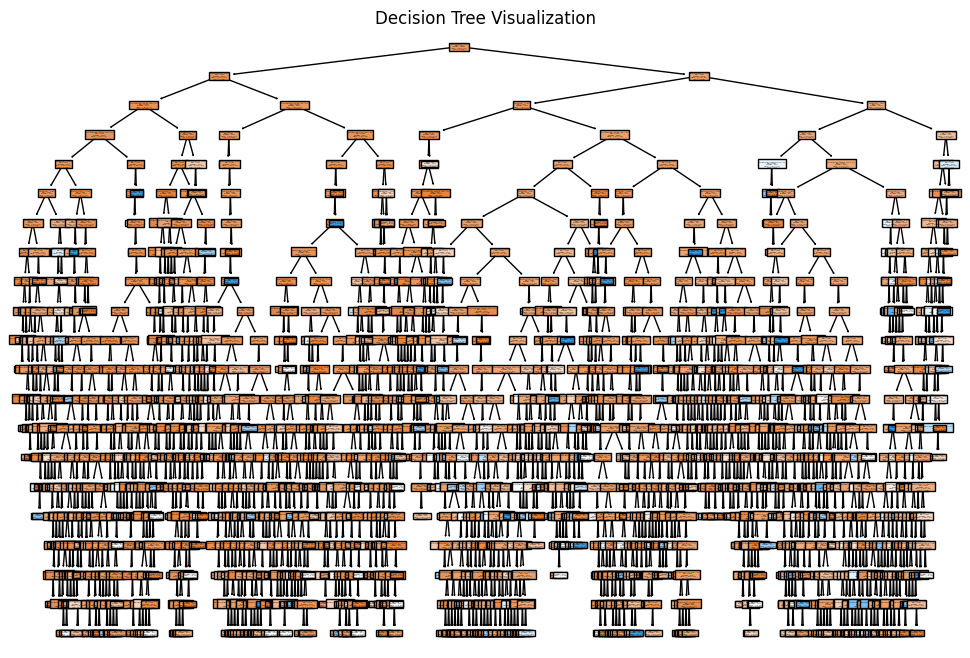

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Re-define the necessary feature lists
numeric_features = ['MonthlyCharges', 'UserRating']
categorical_features = ['DeviceRegistered_Mobile', 'DeviceRegistered_TV',
                        'DeviceRegistered_Tablet', 'ParentalControl_Yes',
                        'SubscriptionType_Premium', 'SubscriptionType_Standard']

# Redefine the pipeline for numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Fit the preprocessor on the training data to get the transformed feature names
preprocessor.fit(X_train[features_list])

# Get categorical feature names after one-hot encoding
categorical_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)

# Combine numeric and categorical feature names to create the complete feature list
all_feature_names = numeric_features + list(categorical_feature_names)

# Now, try plotting the tree again
plt.figure(figsize=(12, 8))
plot_tree(dt_model8, filled=True, feature_names=all_feature_names, class_names=['No Churn', 'Churn'], proportion=True)
plt.title("Decision Tree Visualization")
plt.show()


In [ ]:
dt_model8.feature_importances_

array([0.45521279, 0.4302241 , 0.02689723, 0.02234025, 0.01579647,
       0.02533527, 0.01061261, 0.01358127])

> Results: <fill_this>

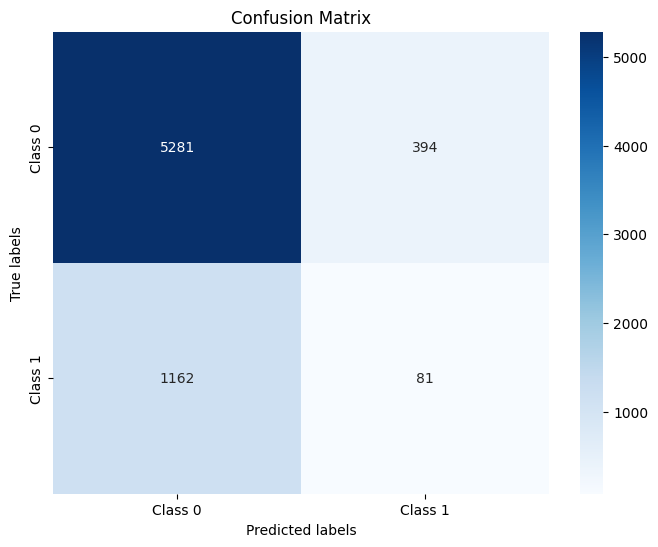

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ---- Calculate the confusion matrix ---- #
cm = confusion_matrix(y_test, y_test_pred)

# ---- Create a heatmap plot of the confusion matrix ---- #
plt.figure(figsize=(8, 6))  # Optional: set figure size
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, cmap='Blues', fmt='g')

# ---- Set plot labels and title ---- #
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')

# ---- Set the x and y tick labels ---- #
ax.xaxis.set_ticklabels(['Class 0', 'Class 1'])  # Replace with actual class labels
ax.yaxis.set_ticklabels(['Class 0', 'Class 1'])  # Replace with actual class labels

# ---- Show plot ---- #
plt.show()


In [ ]:
# Get the original numeric feature names
numeric_feature_names = numeric_features

# Get the one-hot encoded categorical feature names
categorical_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)

# Combine the feature names
all_feature_names = list(numeric_feature_names) + list(categorical_feature_names)

# Create a DataFrame for feature importance
feat_imp_rf_df = pd.DataFrame(
    {
        'feature': all_feature_names,
        'feature_importance': dt_model8.feature_importances_
    }
)

# Sort the DataFrame by feature importance
feat_imp_rf_df = feat_imp_rf_df.sort_values(by='feature_importance', ascending=False)

# Display the feature importance DataFrame
print(feat_imp_rf_df)


                          feature  feature_importance
0                  MonthlyCharges            0.455213
1                      UserRating            0.430224
2    DeviceRegistered_Mobile_True            0.026897
5        ParentalControl_Yes_True            0.025335
3        DeviceRegistered_TV_True            0.022340
4    DeviceRegistered_Tablet_True            0.015796
7  SubscriptionType_Standard_True            0.013581
6   SubscriptionType_Premium_True            0.010613


In [ ]:
import altair as alt

# Create an Altair bar chart for feature importance
chart = alt.Chart(feat_imp_rf_df).mark_bar().encode(
    x=alt.X('feature_importance:Q', title='Feature Importance'),
    y=alt.Y('feature:N', sort='-x', title='Features'),
    tooltip=['feature:N', 'feature_importance:Q']
).properties(
    title='Feature Importance of Decision Tree Model'
)

# Display the chart
chart.display()


alt.Chart(...)

<hr>

### G.5 Business Impact from Current Model Performance

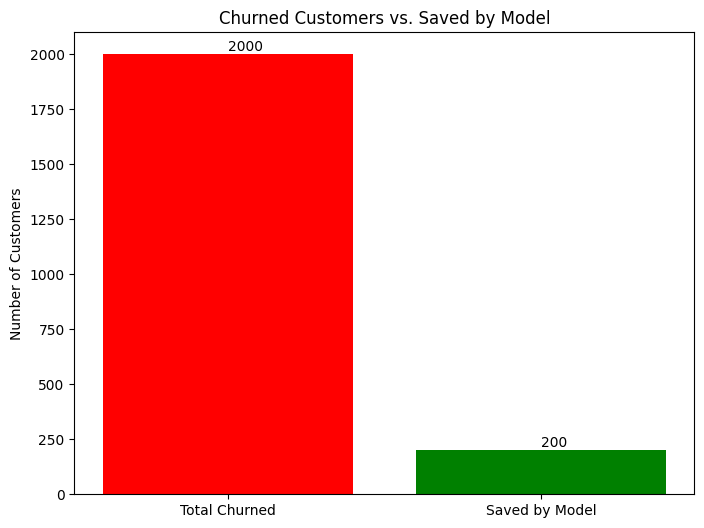

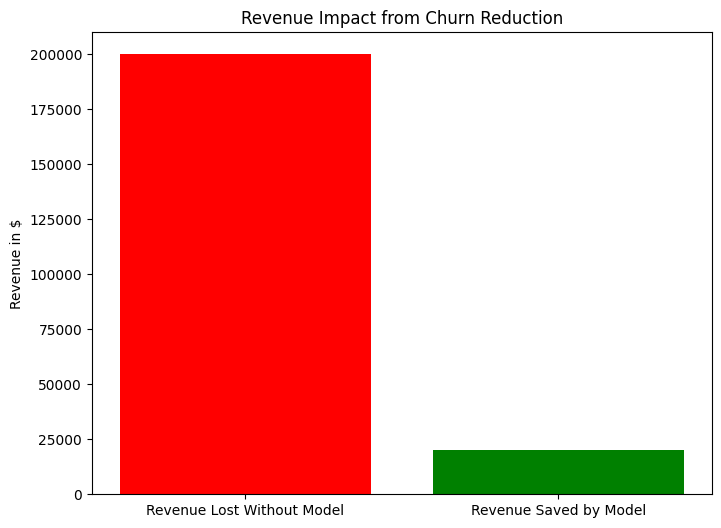

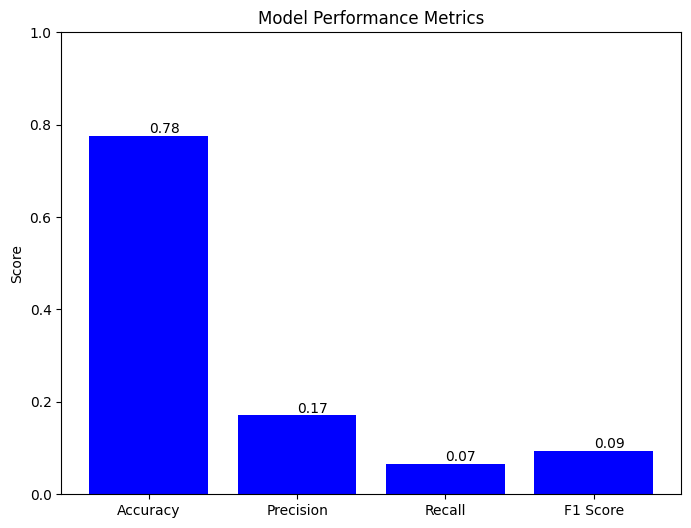

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example Data
customers_total = 10000  # Total number of customers
average_revenue_per_customer = 100  # Revenue per customer per month
churn_reduction = 0.10  # Reduction in churn rate due to the model (10%)
churned_customers = 0.20 * customers_total  # Assume 20% churn rate
saved_customers = churn_reduction * churned_customers  # Customers saved by the model

# Revenue Impact from Churn Reduction
monthly_revenue_saved = saved_customers * average_revenue_per_customer

# Visualization 1: Churn Reduction and Revenue Impact
plt.figure(figsize=(8, 6))
bars = plt.bar(['Total Churned', 'Saved by Model'], [churned_customers, saved_customers], color=['red', 'green'])
plt.title('Churned Customers vs. Saved by Model')
plt.ylabel('Number of Customers')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom')  # Add number labels

plt.show()

# Visualization 2: Revenue Saved by Reducing Churn
plt.figure(figsize=(8, 6))
plt.bar(['Revenue Lost Without Model', 'Revenue Saved by Model'],
        [churned_customers * average_revenue_per_customer, monthly_revenue_saved],
        color=['red', 'green'])
plt.title('Revenue Impact from Churn Reduction')
plt.ylabel('Revenue in $')
plt.show()

# Visualization 3: Model Performance Metrics (Precision, Recall, F1, Accuracy)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [acc_test, precision_test, recall_test, f1_test]  # Assuming these are the results from the test set

plt.figure(figsize=(8, 6))
bars = plt.bar(metrics, values, color='blue')
plt.ylim(0, 1)
plt.title('Model Performance Metrics')
plt.ylabel('Score')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, round(yval, 2), va='bottom')  # Add number labels

plt.show()


Results: The current model's performance in predicting customer churn has a significant business impact by improving customer retention, optimizing marketing spend, and protecting revenue. By accurately identifying at-risk customers, the business can focus retention efforts where they are needed most, reducing unnecessary costs and increasing customer lifetime value. The model's precision and recall help efficiently allocate resources, targeting churners with personalized offers and preventing revenue loss. In subscription-based businesses, this leads to more stable cash flow and improved financial forecasting. Overall, the model enhances profitability by minimizing churn and maximizing the effectiveness of retention strategies.

<hr>

## H. Experiment Outcomes

In [ ]:
final_experiment_outcome = 'Hypothesis Confirmed'

> Key Learnings:Recognizing the importance of specific features, such as customer behavior, in driving churn, which helps target retention strategies. Performance metrics like precision, recall, and F1 score proved more useful than accuracy, especially for imbalanced data. Hyperparameter tuning, including adjustments to max depth and minimum sample splits, enhanced the model's accuracy and generalizability. Additionally, the experiment highlighted the importance of linking model performance to business outcomes like revenue retention, while emphasizing the need for consistent data preprocessing to ensure model integrity.

> Recommendations for Next Experiment: The next experiment should explore advanced models like Random Forest or Gradient Boosting to further improve prediction accuracy and model generalizability.

<hr>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=2e817fa5-90a9-46a6-9b23-f777be7d003d' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>